**训练振荡（Training Oscillation）**

在基于 GRPO 的 LLM 后训练中，例如在 verl / OpenRLHF 等框架的训练曲线中，训练振荡的表现形式和成因各有不同，一般实际日志里有**至少五种可观测的具体形态**。下面逐一拆解。

**每种振荡的成因与数学根源**

**1 Reward 振荡 — 优势方向频繁翻转**

核心在于组内优势估计的方差。当 $G$ 很小时：

$$\text{Var}[\hat{A}_i] = \text{Var}\!\left[\frac{r_i - \mu_r}{\sigma_r}\right] \propto \frac{1}{G}$$

$G=4$ 时方差是 $G=16$ 时的 4 倍。极端情况下，若某 batch 恰好 $G$ 条输出的奖励非常集中（$\sigma_r \approx 0$），分母趋零，所有 $\hat{A}_i$ 都爆炸。verl 中 `group_size`（即 $G$）对应的参数就是这个来源，建议值通常在 8~16。

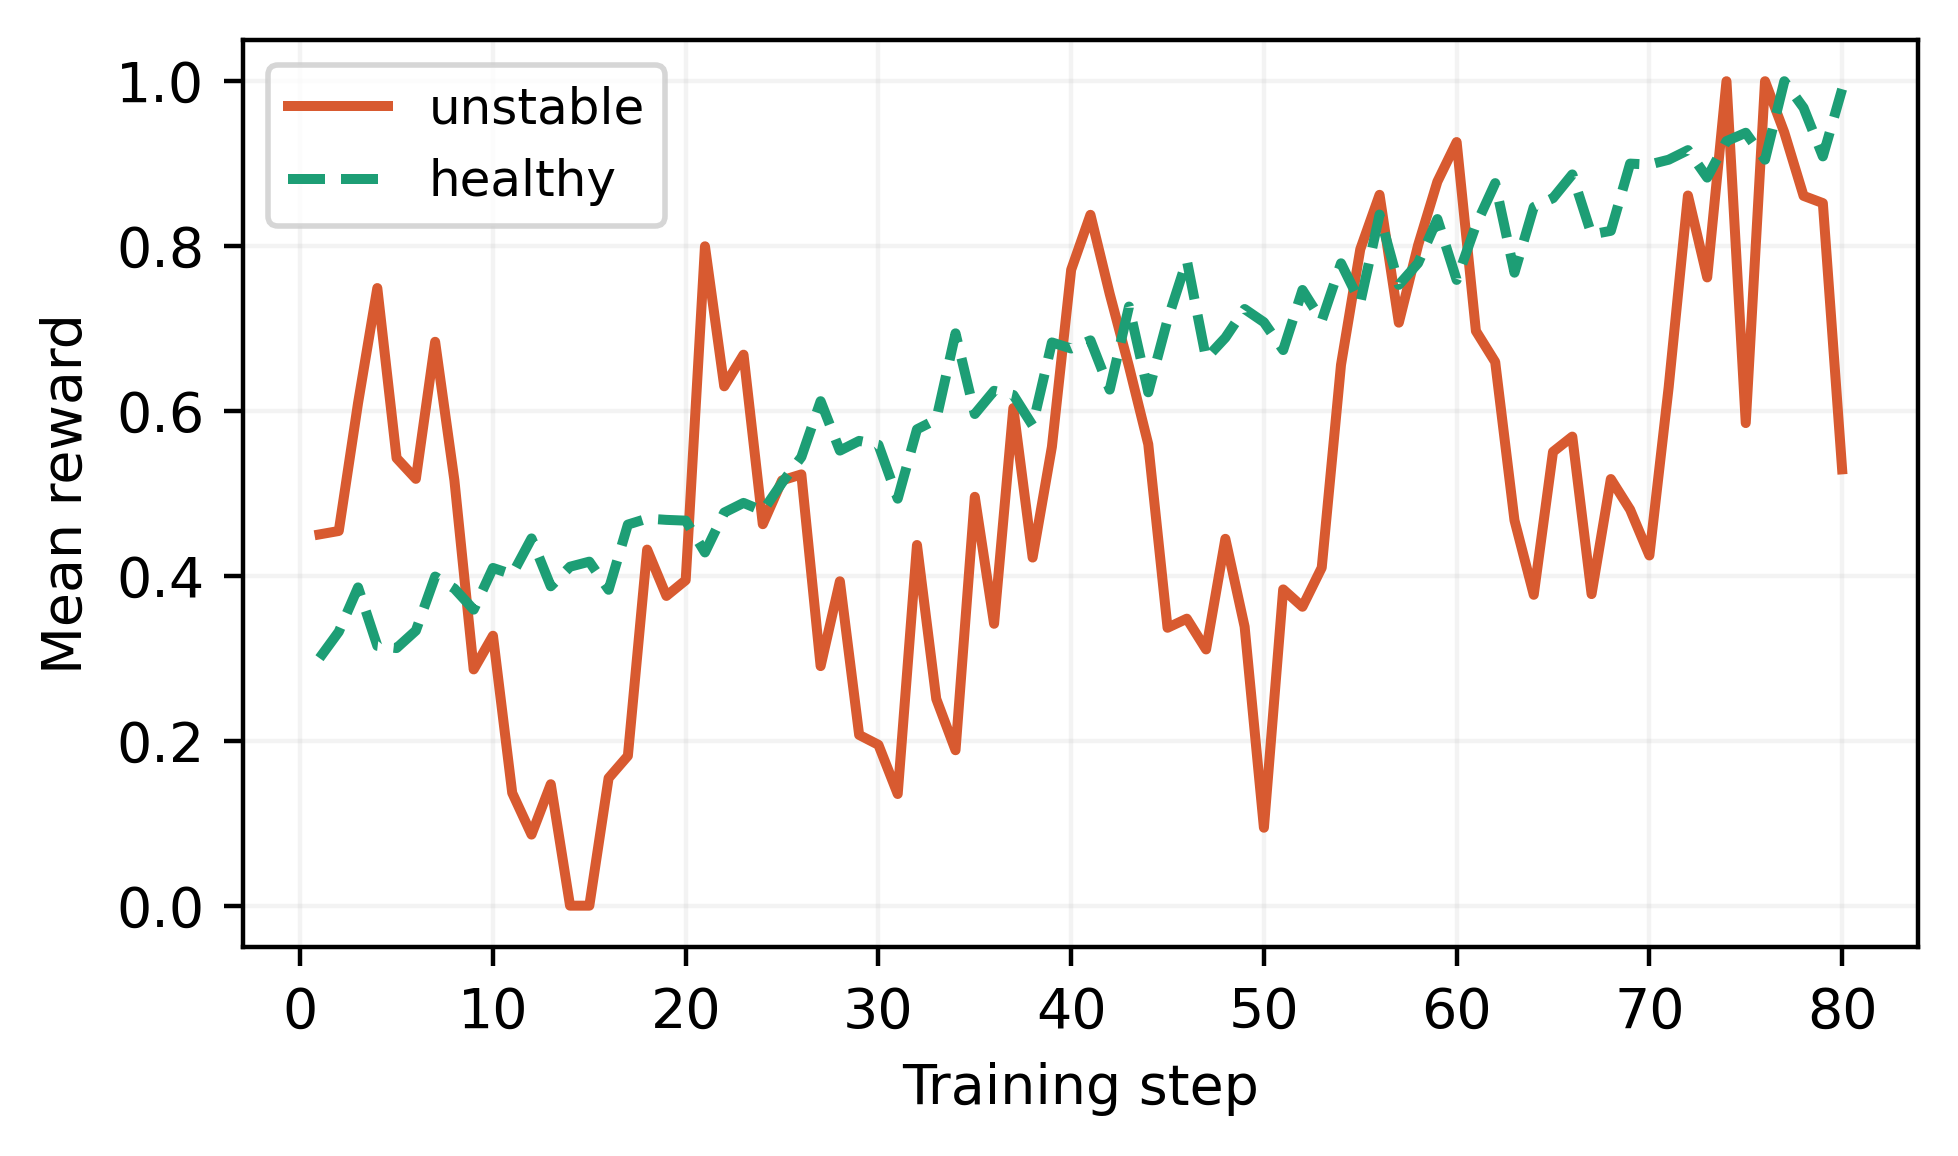

In [13]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
N = 80
steps = np.arange(1, N + 1)

fig, ax = plt.subplots(figsize=(5, 3))
reward_unstable = np.clip(
    0.005 * steps + 0.3 + 0.25 * np.sin(0.35 * steps) + np.random.randn(N) * 0.12,
    0, 1
)
reward_healthy = np.clip(
    0.009 * steps * np.power(0.98, steps * 0.05) + 0.3 + np.random.randn(N) * 0.04,
    0, 1
)
ax.plot(steps, reward_unstable, color="#D85A30", lw=1.8, label="unstable")
ax.plot(steps, reward_healthy,  color="#1D9E75", lw=1.8, ls="--", label="healthy")
ax.set_xlabel("Training step")
ax.set_ylabel("Mean reward")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("osc_1_reward.png", bbox_inches="tight")
plt.gcf().set_dpi(400)
plt.show()

**2 KL 尖刺 — 策略单步偏移过远**

KL 惩罚项的梯度为：

$$\nabla_\theta \left(-\beta\, D_\text{KL}\right) = \beta \nabla_\theta \log \pi_\theta$$

当某个 step 全组奖励都很高（$\hat{A}_i \gg 0$），clip 约束被完全触发（所有 token 都在边界处），梯度瞬间集中，策略大步跳跃，KL 突破到一个新水位，之后由于 KL 惩罚回调，形成一个尖峰。在 verl 中，`kl_ctrl.kl_coef`（即 $\beta$）设太小，或者 `num_rollout_workers` 很多但 `rollout_batch_size` 没有相应增大时，每个 mini-batch 中高质量样本的比例偶尔会很高，触发这个情况。

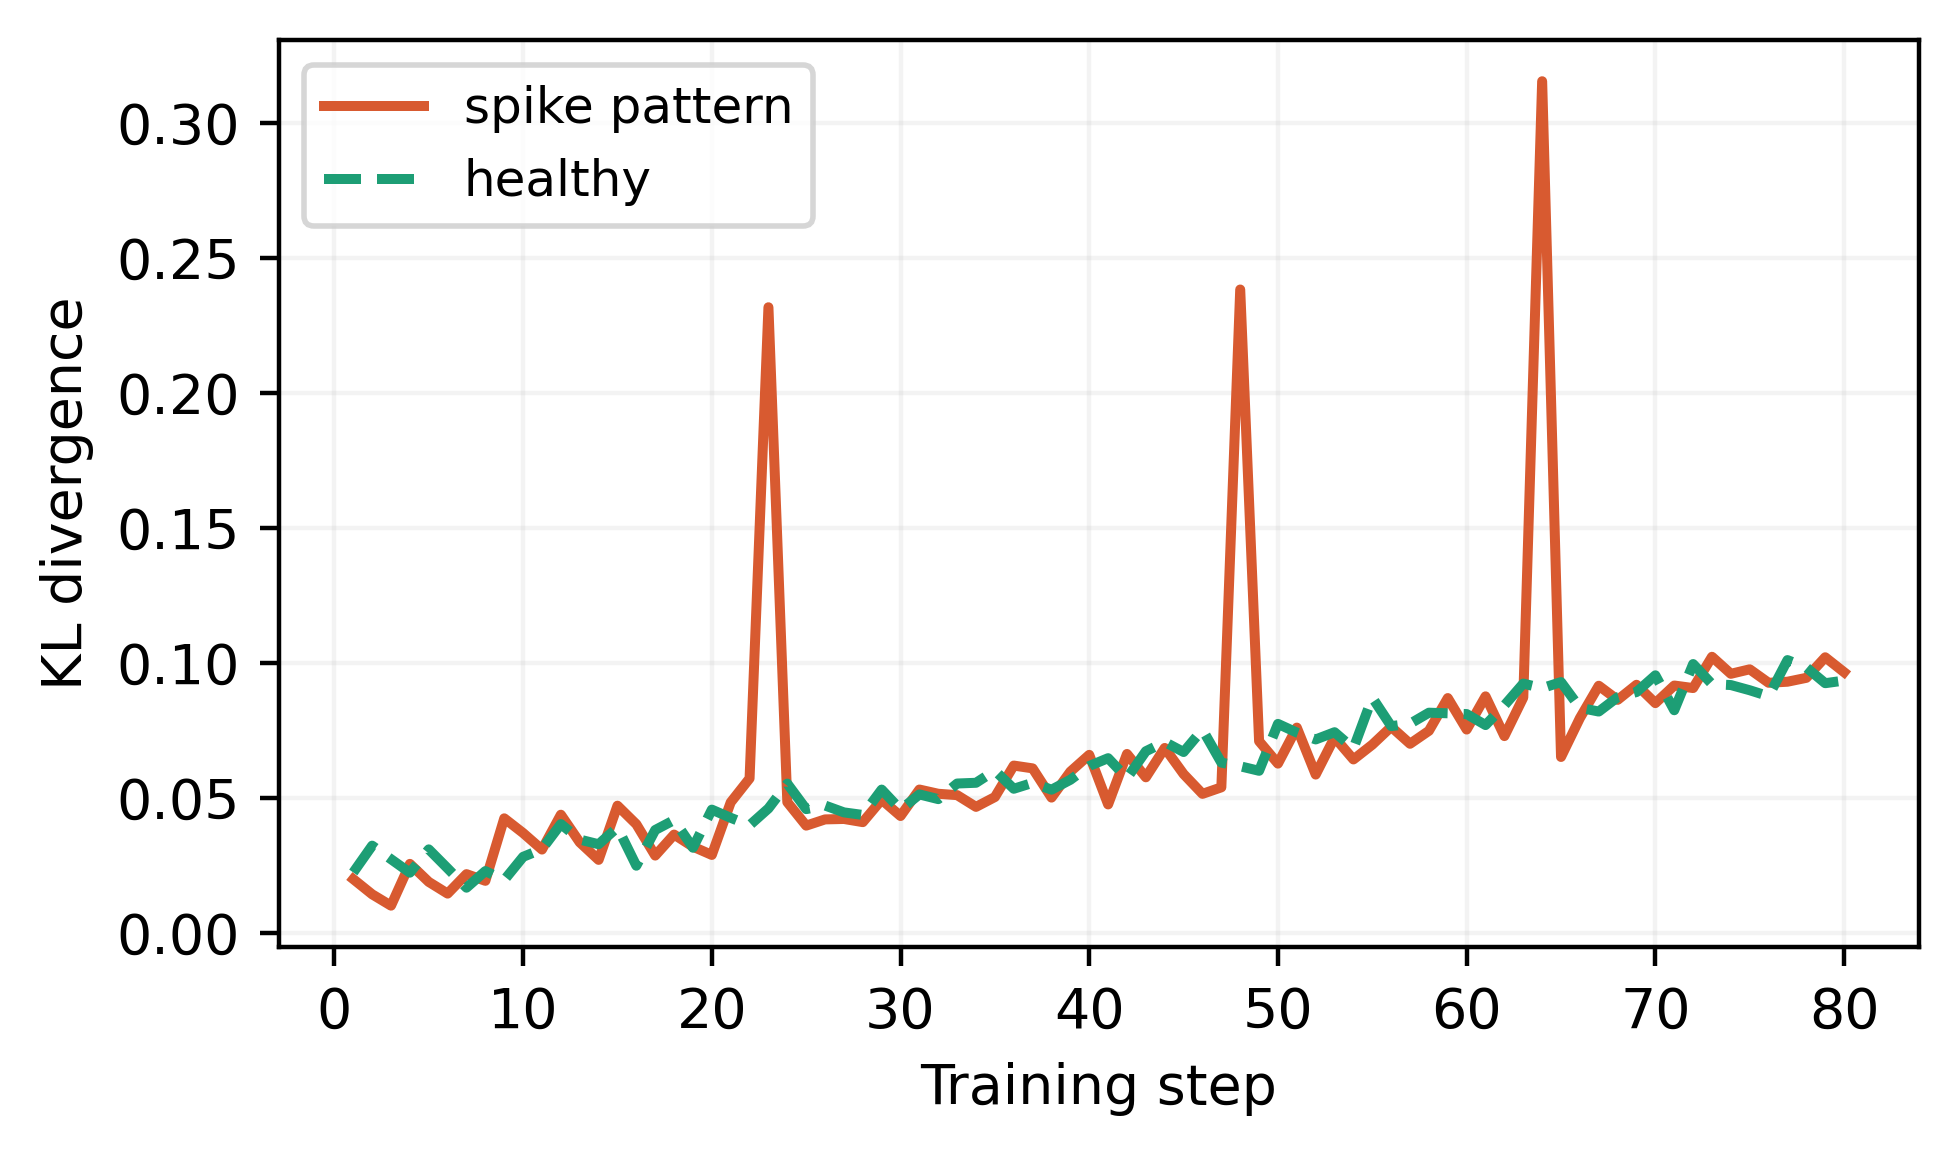

In [16]:
fig, ax = plt.subplots(figsize=(5, 3))
kl_spike = 0.02 + 0.001 * steps + np.random.randn(N) * 0.008
kl_spike[22] += 0.20
kl_spike[47] += 0.17
kl_spike[63] += 0.22
kl_spike = np.clip(kl_spike, 0, None)
kl_healthy = 0.001 * steps + 0.02 + np.random.randn(N) * 0.005
ax.plot(steps, kl_spike,   color="#D85A30", lw=1.8, label="spike pattern")
ax.plot(steps, kl_healthy, color="#1D9E75", lw=1.8, ls="--", label="healthy")
ax.set_xlabel("Training step")
ax.set_ylabel("KL divergence")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("osc_2_kl_spike.png", bbox_inches="tight")
plt.gcf().set_dpi(400)
plt.show()

**3 输出长度抖动 — 策略在两个局部最优间跳跃**

这是 GRPO 训练数学推理任务时最有名的现象，在 DeepSeek-R1 的技术报告中被明确提及。本质是**双峰奖励分布**：

- 短输出若恰好答对，奖励高；若答错，奖励低
- 长思维链若答对，奖励也高，但生成成本高

策略在两个分布间振荡，因为在组内相对比较中，"短且对"有时胜过"长且对"（节省了 token 预算，该 rollout 的归一化分母更小），导致长度不稳定。verl 中可以通过对 `response_length` 加入 length reward shaping 来缓解。

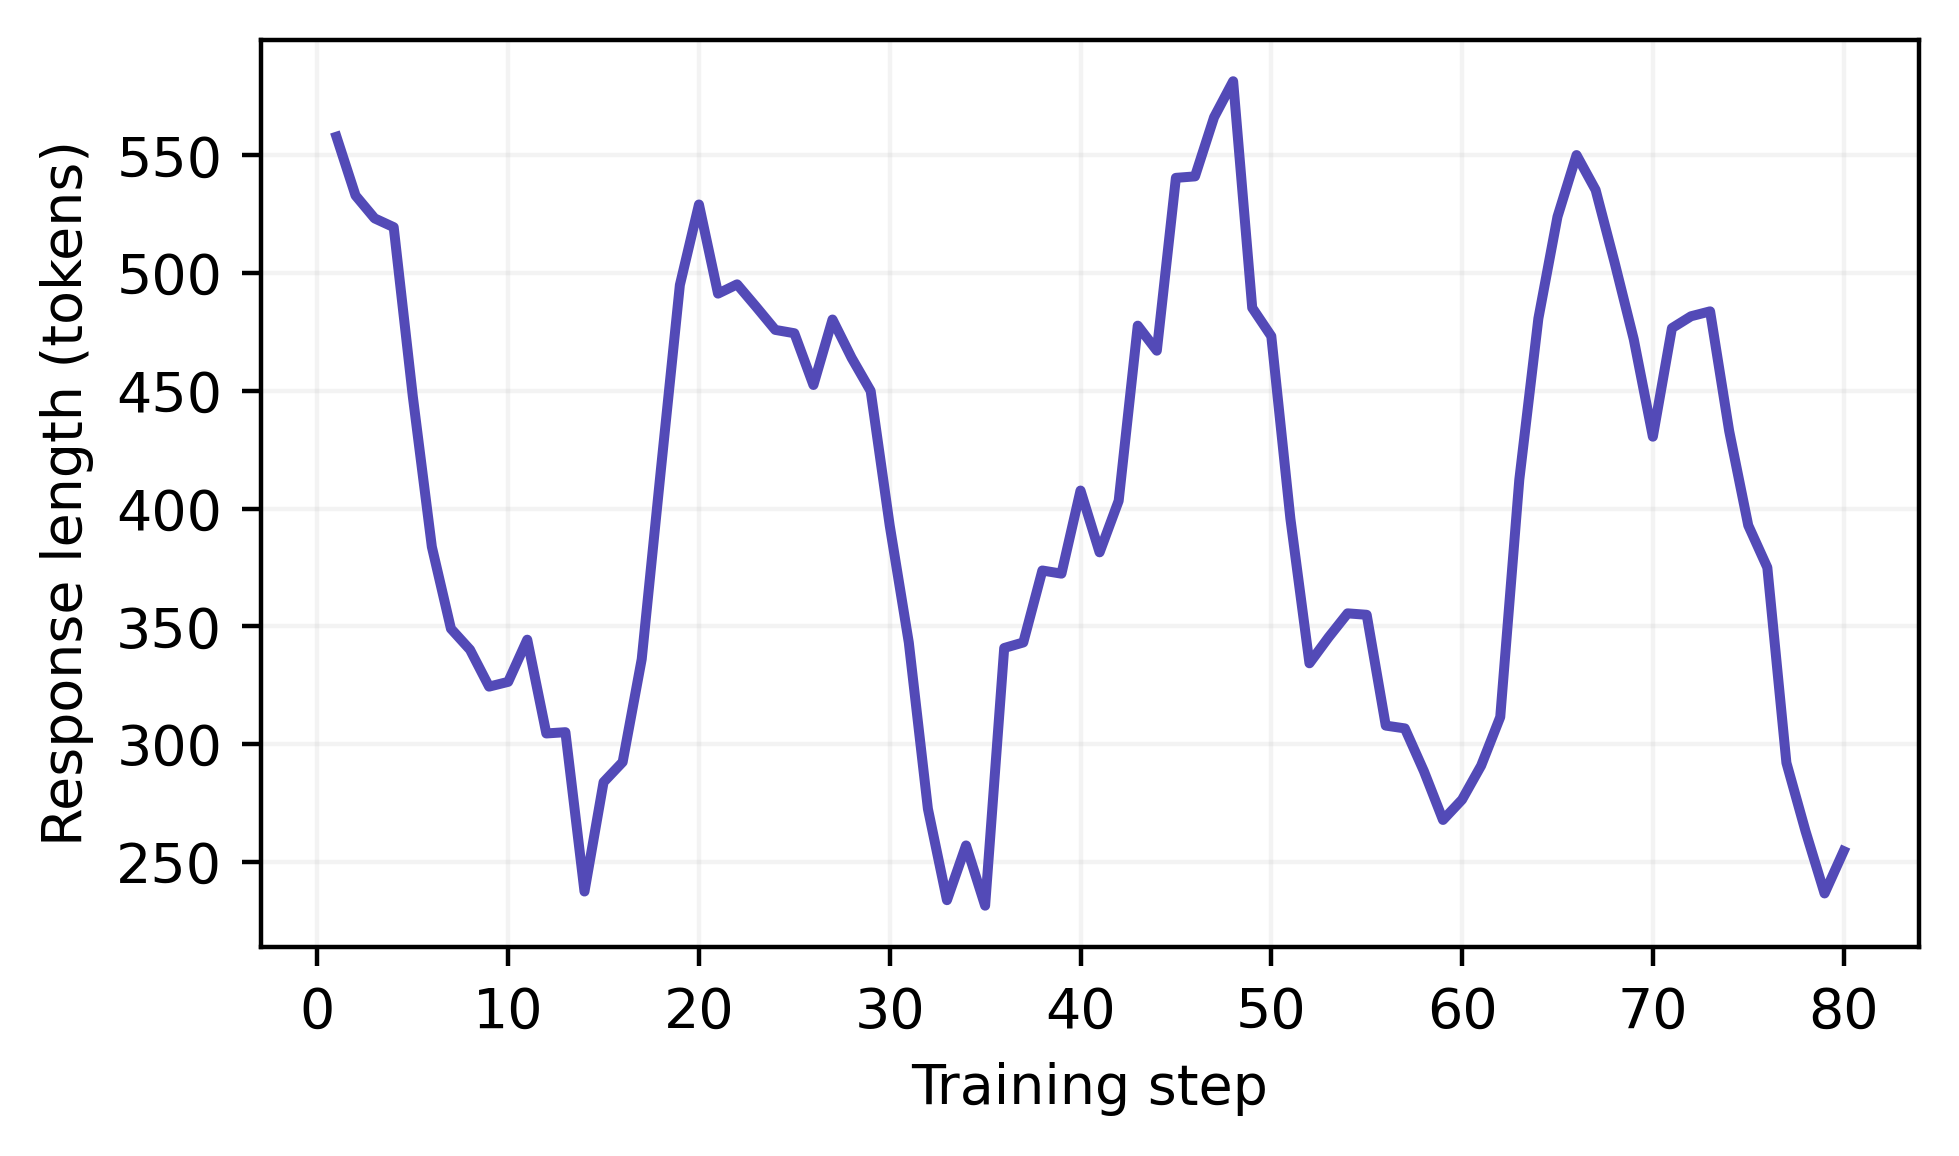

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))
resp_len = (
    400
    + 120 * np.sin(0.28 * steps + 1.2)
    + 50  * np.sin(0.70 * steps)
    + np.random.randn(N) * 20
)
ax.plot(steps, resp_len, color="#534AB7", lw=1.8)
ax.set_xlabel("Training step")
ax.set_ylabel("Response length (tokens)")
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("osc_3_resp_len.png", bbox_inches="tight")
plt.gcf().set_dpi(400)
plt.show()

**4 Clip 比例波动 — 更新步长忽大忽小**

定义 clip fraction 为：

$$\text{clip\_frac} = \frac{1}{N_\text{tokens}} \sum_{i,t} \mathbf{1}\!\left[r_{i,t}(\theta) \notin [1-\varepsilon, 1+\varepsilon]\right]$$

健康训练中它应稳定在约 10~25%。若 `num_mini_epochs`（verl 中同一批 rollout 数据被重复用于反向传播的次数）设太大（如 $>4$），则第二、三轮 mini-batch 更新时 $\theta$ 已离 $\theta_{old}$ 较远，clip fraction 爆升，本轮后续梯度几乎全被截断，下一轮 rollout 完全基于新分布，又导致巨大的分布差异，产生周期性的"步大—截断—步小—步大"循环。

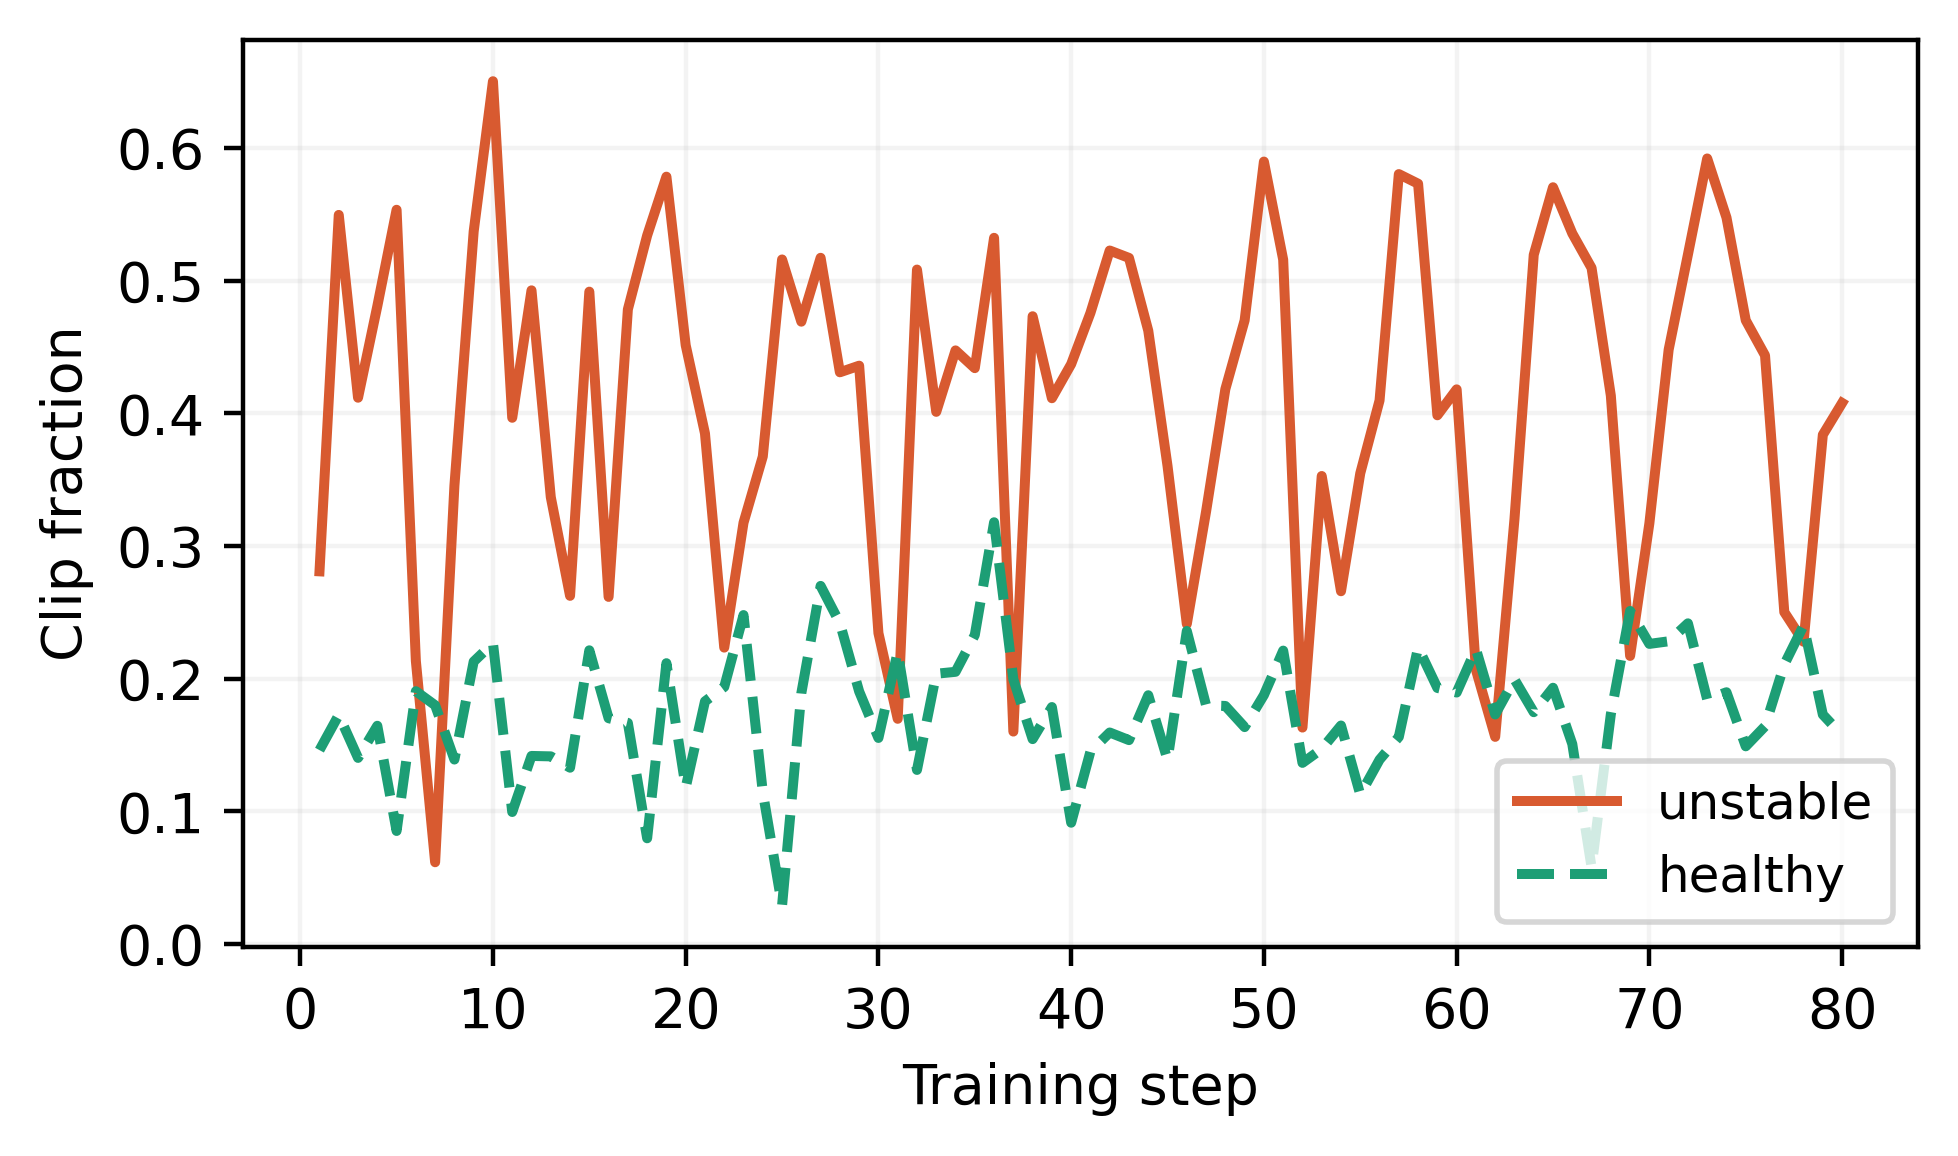

In [26]:
fig, ax = plt.subplots(figsize=(5, 3))
clip_unstable = np.clip(
    0.22 + 0.28 * np.abs(np.sin(0.4 * steps + 0.5)) + np.random.randn(N) * 0.08,
    0, 0.8
)
clip_healthy = np.clip(0.18 + np.random.randn(N) * 0.05, 0, 0.5)
ax.plot(steps, clip_unstable, color="#D85A30", lw=1.8, label="unstable")
ax.plot(steps, clip_healthy,  color="#1D9E75", lw=1.8, ls="--", label="healthy")
ax.set_xlabel("Training step")
ax.set_ylabel("Clip fraction")
ax.legend(fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("osc_4_clip_frac.png", bbox_inches="tight")
plt.gcf().set_dpi(400)
plt.show()

**5 熵坍缩 — 最终形态，训练完全失效**

策略熵定义为：

$$H(\pi_\theta) = -\mathbb{E}_{o \sim \pi_\theta}\!\left[\log \pi_\theta(o)\right]$$

坍缩的成因链路：过度优化某类奖励 → 策略对高奖励输出的概率趋向 1 → 组内 $G$ 条输出几乎完全相同 → $\sigma_r \to 0$ → 优势估计变为 `NaN` 或无意义常数。在 verl 里，`entropy_coeff` 是抵御熵坍缩的显式正则化项，但默认值有时为 0。

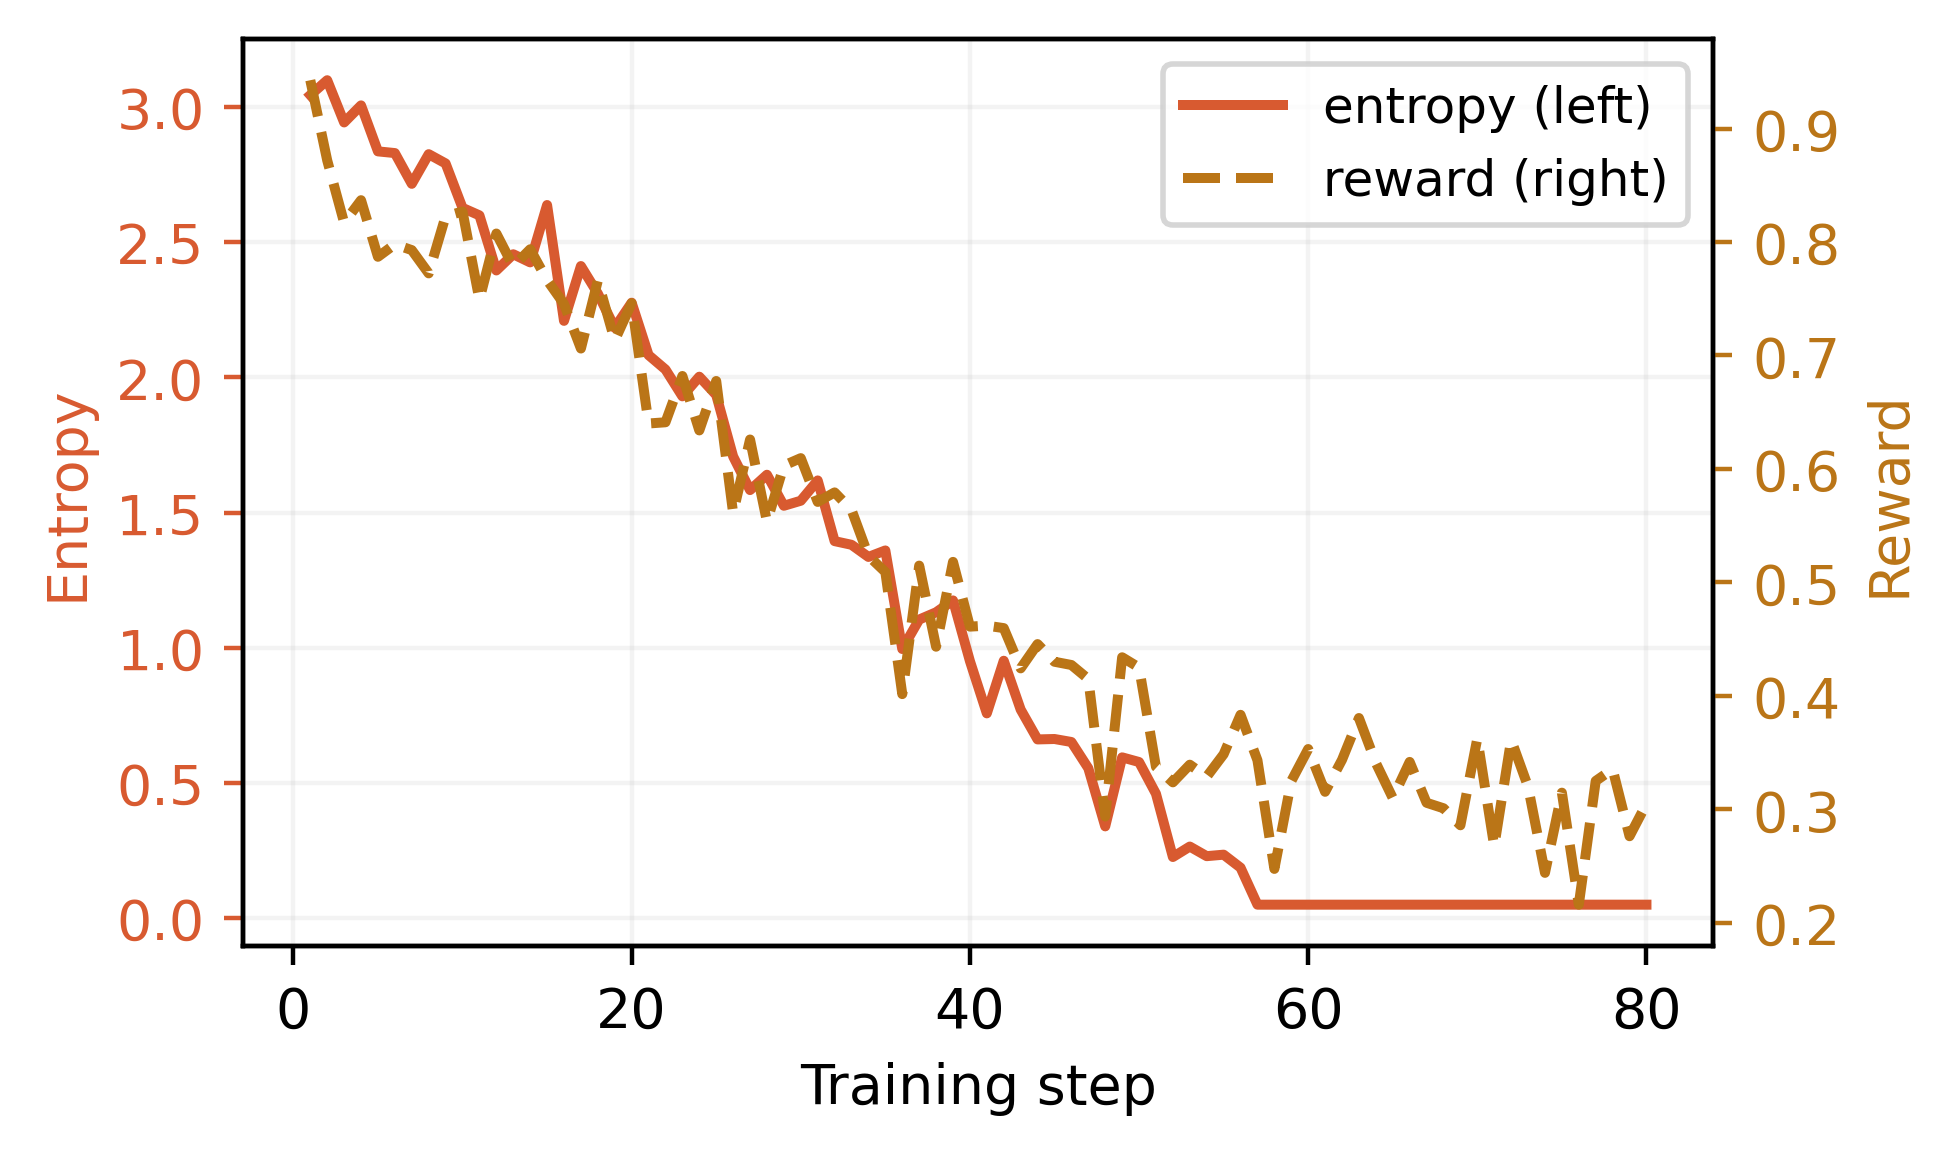

In [30]:
fig, ax = plt.subplots(figsize=(5, 3))
entropy_collapse = np.maximum(0.05, 3.2 - 0.055 * steps + np.random.randn(N) * 0.10)
reward_collapse  = np.maximum(
    0.05,
    0.3 + (entropy_collapse - 0.05) / 3.15 * 0.6 + np.random.randn(N) * 0.04
)
ax_r = ax.twinx()
ax.plot(steps,   entropy_collapse, color="#D85A30", lw=1.8, label="entropy (left)")
ax_r.plot(steps, reward_collapse,  color="#BA7517", lw=1.8, ls="--", label="reward (right)")
ax.set_xlabel("Training step")
ax.set_ylabel("Entropy",  color="#D85A30")
ax_r.set_ylabel("Reward", color="#BA7517")
ax.tick_params(axis="y", colors="#D85A30")
ax_r.tick_params(axis="y", colors="#BA7517")
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax_r.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.savefig("osc_5_entropy.png", dpi=400, bbox_inches="tight")
plt.gcf().set_dpi(400)
plt.show()

**振荡的监控信号与对应处置总结**

| 观测到的信号 | verl 对应参数 | 处置方向 |
|---|---|---|
| reward 曲线震荡，方差大 | `group_size` | 增大 $G$（8 → 16） |
| KL 出现周期性尖刺 | `kl_coef` / `kl_target` | 增大 $\beta$ 或启用自适应 KL |
| 输出长度周期性长短交替 | reward shaping | 加入 length penalty 或 format reward |
| clip fraction > 0.5 且抖动 | `num_mini_epochs`, `lr` | 降低 mini-epochs（≤2）或降低学习率 |
| 熵单调下降至接近 0 | `entropy_coeff` | 设置正值（如 0.001） |
| loss 突然跳变为 NaN | gradient clipping | 启用 `max_grad_norm`（如 1.0） |

实时检测振荡的监控函数。这套监控逻辑在 verl 中可以挂在 `trainer.py` 的 `log_metrics` 回调里，每个 `rollout_epoch` 调用一次，实时预警。